## Data Understanding

In [2]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Load fraud transaction dataset
file_path = "../data/creditcard.csv"

df = pd.read_csv(file_path)

In [4]:
df.head(10)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
5,2.0,-0.425966,0.960523,1.141109,-0.168252,0.420987,-0.029728,0.476201,0.260314,-0.568671,...,-0.208254,-0.559825,-0.026398,-0.371427,-0.232794,0.105915,0.253844,0.081080,3.67,0
6,4.0,1.229658,0.141004,0.045371,1.202613,0.191881,0.272708,-0.005159,0.081213,0.464960,...,-0.167716,-0.270710,-0.154104,-0.780055,0.750137,-0.257237,0.034507,0.005168,4.99,0
7,7.0,-0.644269,1.417964,1.074380,-0.492199,0.948934,0.428118,1.120631,-3.807864,0.615375,...,1.943465,-1.015455,0.057504,-0.649709,-0.415267,-0.051634,-1.206921,-1.085339,40.80,0
8,7.0,-0.894286,0.286157,-0.113192,-0.271526,2.669599,3.721818,0.370145,0.851084,-0.392048,...,-0.073425,-0.268092,-0.204233,1.011592,0.373205,-0.384157,0.011747,0.142404,93.20,0
9,9.0,-0.338262,1.119593,1.044367,-0.222187,0.499361,-0.246761,0.651583,0.069539,-0.736727,...,-0.246914,-0.633753,-0.120794,-0.385050,-0.069733,0.094199,0.246219,0.083076,3.68,0


**Initial Inspection**

In [5]:
df.shape

(284807, 31)

In [6]:
"""df_info = pd.DataFrame({
    "Column": df.columns,
    "Dtype": df.dtypes.values,
    "NonNull": df.notnull().sum().values,
    "Null": df.isnull().sum().values
})"""

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [7]:
df.isnull().sum().sum()

np.int64(0)

In [8]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


**Target Variable (Fraud Distribution/Percentage)**

In [9]:
# df["Class"].value_counts()
"""fraud_distribution = (
    df["Class"]
    .value_counts()
    .reset_index()
)

fraud_distribution"""

target_vars = pd.DataFrame(
    {
        "Class Code": [0, 1],
        "Class Name": ["Legitimate", "Fraudulent"],
        "Count": [(df["Class"] == 0).sum(), (df["Class"] == 1).sum()],
        "Percentage": [
            round((df["Class"] == 0).sum() * 100 / df.shape[0], 2),
            round((df["Class"] == 1).sum() * 100 / df.shape[0], 2),
        ],
    }
)

target_vars

,Class Code,Class Name,Count,Percentage
0,0,Legitimate,284315,99.83
1,1,Fraudulent,492,0.17


**Executive Observation**

**Risk of Class Imbalance**

Fraudulent transactions are extremely rare compared to legitimate transactions.

As a result, a model can achieve very high accuracy simply by predicting every transaction as legitimate.

This makes `Precision`, `Recall`, and `F1-Score` more informative evaluation metrics than accuracy alone, as they better measure a model's ability to detect fraudulent transactions.

---

## Fraud Behavior Profiling

**Transaction Groups**

In [10]:
# Separate legitimate and fraudulent transactions.

legit_df = df[df["Class"] == 0]

fraud_df = df[df["Class"] == 1]

**Compare Amounts**

In [ ]:
amount_comparison = pd.DataFrame(
    {
        "Metric": [
            "Average Transaction Amount",
            "Median Transaction Amount",
            "Maximum Transaction Amount",
            "Amount that 99% of Transaction bellow it",
        ],
        "Legitimate": [
            round(legit_df["Amount"].mean(), 2),
            legit_df["Amount"].median(),
            legit_df["Amount"].max(),
            round(legit_df["Amount"].quantile(0.99), 2),
        ],
        "Fraudulent": [
            round(fraud_df["Amount"].mean(), 2),
            fraud_df["Amount"].median(),
            fraud_df["Amount"].max(),
            round(fraud_df["Amount"].quantile(0.99), 2),
        ],
    }
)

amount_comparison

,Metric,Legitimate,Fraudulent
0,Average Transaction Amount,88.29,122.21
1,Median Transaction Amount,22.00,9.25
2,Maximum Transaction Amount,25691.16,2125.87
3,Amount that 99% of Transaction bellow it,1016.97,1357.43


**Executive Thinking**

Fraudulent transactions have a higher average amount (`122.21`) than legitimate transactions (`88.29`).

The lower median amount (`9.25`) suggests that many fraudulent transactions are relatively small.

Smaller transactions are less likely to attract attention or trigger fraud detection systems.

Transaction amounts vary widely in both groups. While fraudulent transactions have a higher average amount and 99th percentile (`1,357.43` vs. `1,016.97`), legitimate transactions can still reach much larger values (`25,691.16`). Therefore, transaction amount alone cannot reliably identify fraud.

**Transaction Amount Distribution**

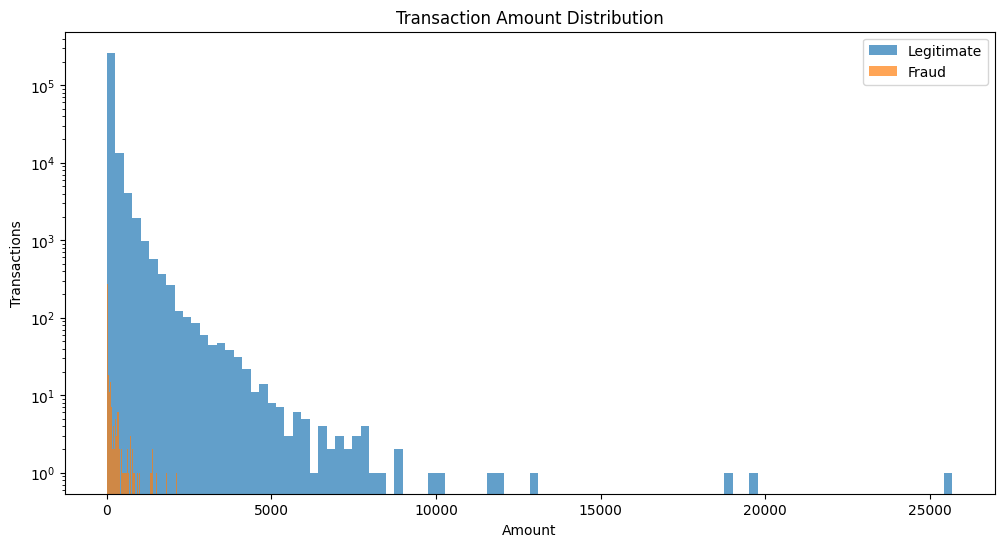

In [ ]:
plt.figure(figsize=(12, 6))

plt.hist(legit_df["Amount"], bins=100, alpha=0.7, label="Legitimate")

plt.hist(fraud_df["Amount"], bins=100, alpha=0.7, label="Fraud")

plt.yscale("log")

plt.legend()

plt.title("Transaction Amount Distribution")

plt.xlabel("Amount")

plt.ylabel("Transactions")

plt.show()

**Time-Based Analysis**

In [ ]:
# Convert elapsed seconds into hours from the beginning
# of the observation period.

df["Hour"] = (df["Time"] / 3600).astype(int)
fraud_df["Hour"] = (df["Time"] / 3600).astype(int)
legit_df["Hour"] = (df["Time"] / 3600).astype(int)

**KDE Distribution by Class**

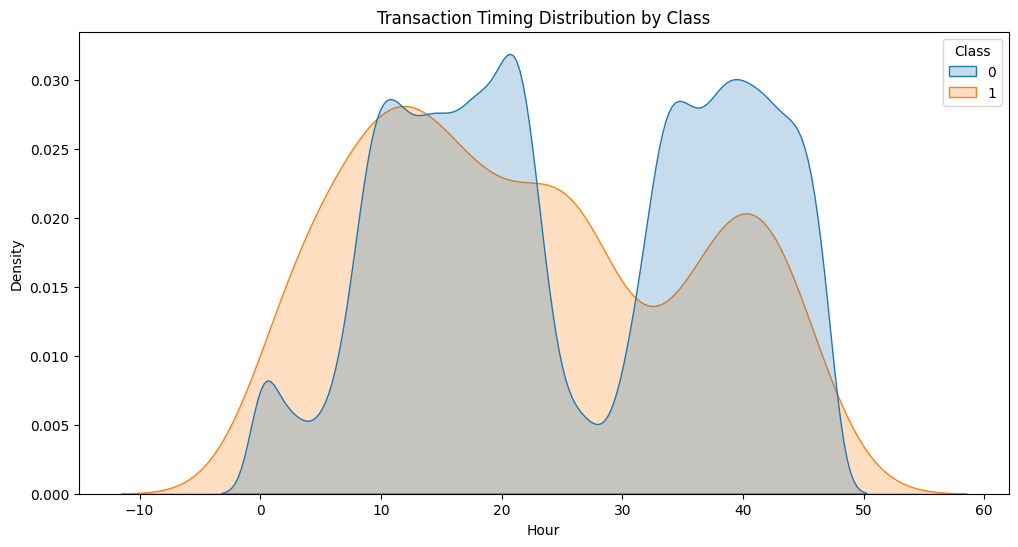

In [ ]:
plt.figure(figsize=(12, 6))

sns.kdeplot(data=df, x="Hour", hue="Class", fill=True, common_norm=False)

plt.title("Transaction Timing Distribution by Class")

plt.xlabel("Hour")
plt.ylabel("Density")

plt.show()

**Fraud Transactions Only**

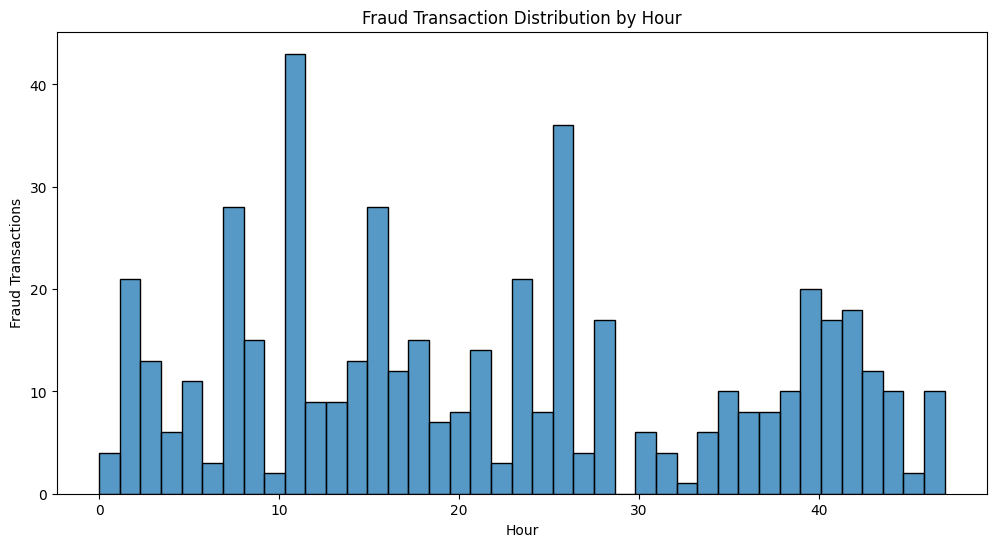

In [ ]:
plt.figure(figsize=(12, 6))

sns.histplot(
    fraud_df["Hour"],
    bins=41,  # each bar represents 12 fraud Transaction so: 1-12, 13-24, 25-36 ... 480-492
)

plt.title("Fraud Transaction Distribution by Hour")

plt.xlabel("Hour")
plt.ylabel("Fraud Transactions")

plt.show()

**Fraud Volume by Hour**

In [ ]:
fraud_by_hour = fraud_df.groupby("Hour").size().reset_index(name="FraudCount")

fraud_by_hour

,Hour,FraudCount
0,0,2
1,1,2
2,2,21
3,3,13
4,4,6
5,5,11
6,6,3
7,7,23
8,8,5
9,9,15


**Visualization**

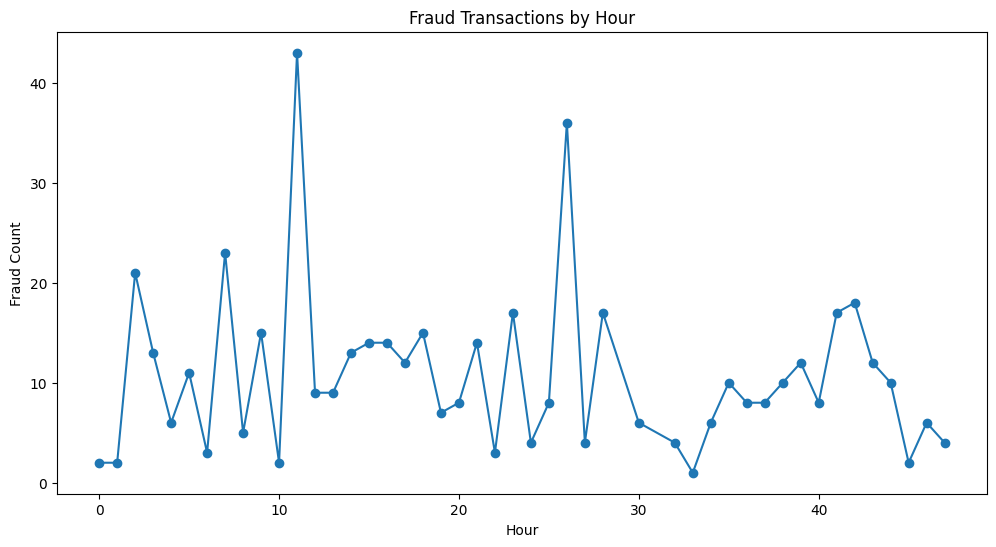

In [ ]:
plt.figure(figsize=(12, 6))

plt.plot(fraud_by_hour["Hour"], fraud_by_hour["FraudCount"], marker="o")

plt.title("Fraud Transactions by Hour")

plt.xlabel("Hour")
plt.ylabel("Fraud Count")

plt.show()

**Fraud Rate by Hour**

In [ ]:
fraud_rate_by_hour = (df.groupby("Hour")["Class"].mean().mul(100)).reset_index(
    name="FraudRate"
)

fraud_rate_by_hour

,Hour,FraudRate
0,0,0.050467
1,1,0.090212
2,2,1.332487
3,3,0.713893
4,4,0.554529
5,5,0.654372
6,6,0.163845
7,7,0.682898
8,8,0.096544
9,9,0.190404


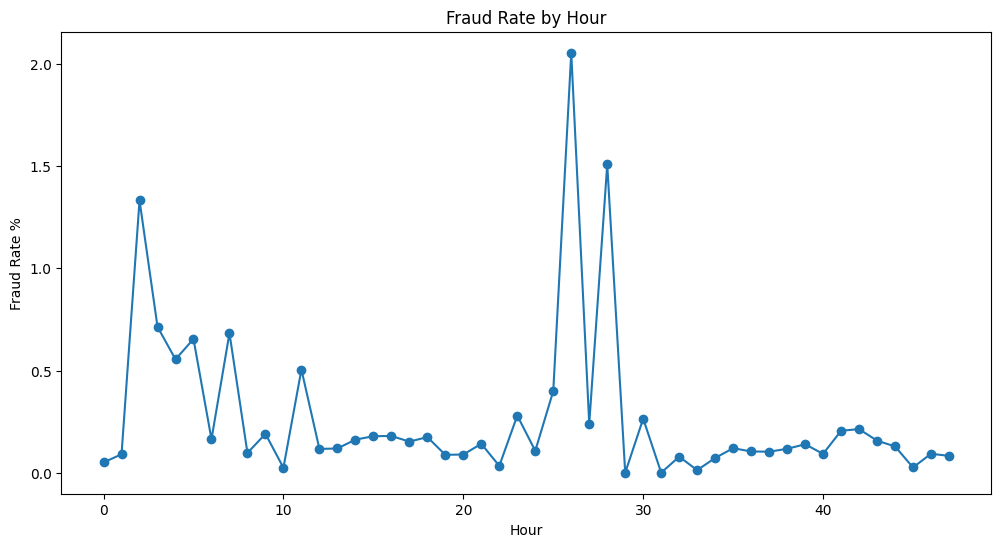

In [ ]:
plt.figure(figsize=(12, 6))

plt.plot(fraud_rate_by_hour["Hour"], fraud_rate_by_hour["FraudRate"], marker="o")

plt.title("Fraud Rate by Hour")

plt.xlabel("Hour")
plt.ylabel("Fraud Rate %")

plt.show()

**Classes rate by Hour**

In [ ]:
hourly_rates = df.groupby("Hour")["Class"].mean().mul(100).reset_index(name="FraudRate")

hourly_rates["LegitRate"] = 100 - hourly_rates["FraudRate"]

hourly_rates

,Hour,FraudRate,LegitRate
0,0,0.050467,99.949533
1,1,0.090212,99.909788
2,2,1.332487,98.667513
3,3,0.713893,99.286107
4,4,0.554529,99.445471
5,5,0.654372,99.345628
6,6,0.163845,99.836155
7,7,0.682898,99.317102
8,8,0.096544,99.903456
9,9,0.190404,99.809596


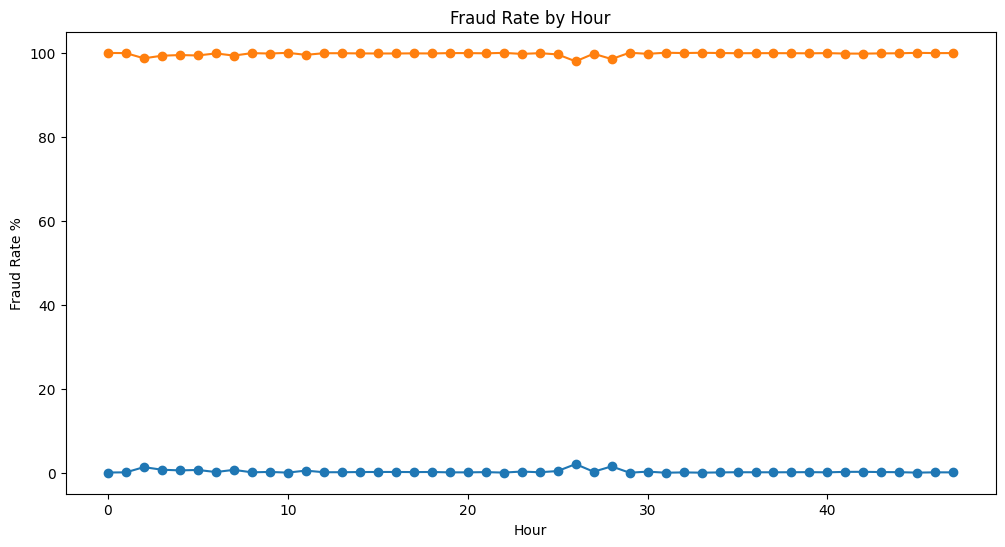

In [ ]:
plt.figure(figsize=(12, 6))

plt.plot(hourly_rates["Hour"], hourly_rates["FraudRate"], marker="o")

plt.plot(hourly_rates["Hour"], hourly_rates["LegitRate"], marker="o")

plt.title("Fraud Rate by Hour")

plt.xlabel("Hour")
plt.ylabel("Fraud Rate %")

plt.show()

In [ ]:
hourly_activity = df.groupby(["Hour", "Class"]).size().reset_index(name="Count")

hourly_activity["ClassName"] = hourly_activity["Class"].map(
    {0: "Legitimate", 1: "Fraudulent"}
)

hourly_activity

,Hour,Class,Count,ClassName
0,0,0,3961,Legitimate
1,0,1,2,Fraudulent
2,1,0,2215,Legitimate
3,1,1,2,Fraudulent
4,2,0,1555,Legitimate
...,...,...,...,...
89,45,1,2,Fraudulent
90,46,0,6458,Legitimate
91,46,1,6,Fraudulent
92,47,0,4852,Legitimate


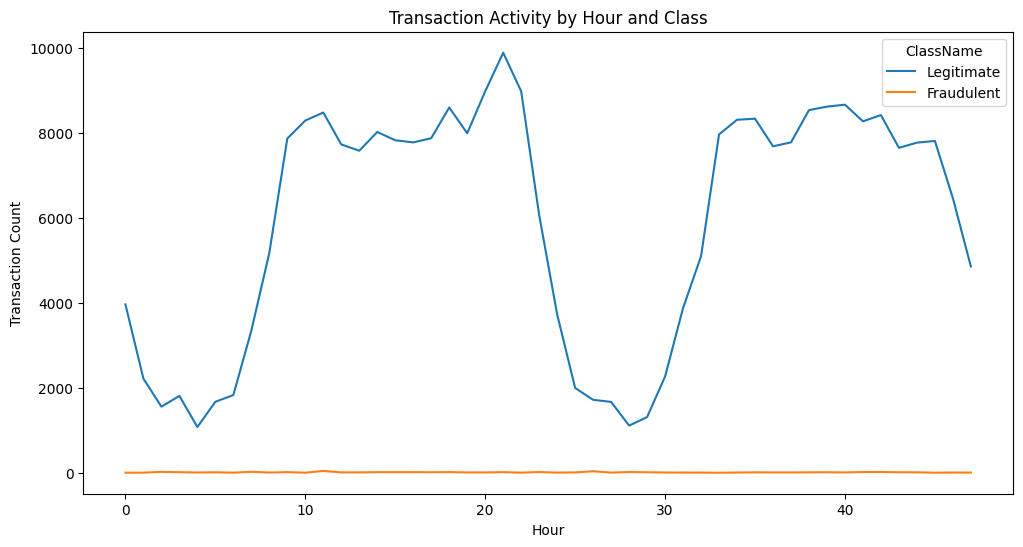

In [ ]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=hourly_activity,
    x="Hour",
    y="Count",
    hue="ClassName",
)

plt.title("Transaction Activity by Hour and Class")

plt.xlabel("Hour")
plt.ylabel("Transaction Count")

plt.show()

**Financial Exposure**

In [ ]:
fraud_loss = fraud_df["Amount"].sum()

total_volume = df["Amount"].sum()

loss_percentage = round((fraud_loss / total_volume) * 100, 2)

fraud_loss_summ_table = pd.DataFrame(
    {
        "Metric": [
            "Total Transaction Volume",
            "Total Fraud Loss",
            "Fraud Loss Percentage",
        ],
        "Value": [
            f"{total_volume:,.2f}",
            f"{fraud_loss:,.2f}",
            f"{loss_percentage:.2f}%",
        ],
    }
)

fraud_loss_summ_table

,Metric,Value
0,Total Transaction Volume,"25,162,590.01"
1,Total Fraud Loss,"60,127.97"
2,Fraud Loss Percentage,0.24%


**Executive summary**

- Fraud transactions are most concentrated around `Hour 11` and `Hour 26`, where the highest numbers of fraud cases were observed.

- The most probable hours for fraud require `Fraud Rate by Hour` analysis. High fraud counts do not necessarily imply high fraud risk because transaction volumes vary by hour.

- Fraud activity appears to follow identifiable timing patterns rather than being evenly distributed across the observation period.

- Yes. Transaction timing could be a useful feature in a fraud detection model when combined with behavioral and transaction-related variables.

- Banks could use these findings to:
  - Increase monitoring during higher-risk periods.
  - Trigger additional transaction verification.
  - Incorporate timing into dynamic risk scoring.
  - Prioritize fraud alerts during periods of elevated fraud activity.

---

## Risk Scoring Engine

**Create RiskScore Column**

In [26]:
# Initialize risk score.

df["RiskScore"] = 0

**High Amount Risk**

In [27]:
high_amount_threshold = df["Amount"].quantile(0.90)
high_amount_threshold

np.float64(203.0)

In [ ]:
df.loc[df["Amount"] >= high_amount_threshold, "RiskScore"] += 25

**High-Risk Hours**

In [ ]:
fraud_rate_by_hour.sort_values(by="FraudRate", ascending=False).head(3)

,Hour,FraudRate
26,26,2.054795
28,28,1.508429
2,2,1.332487


In [ ]:
high_risk_hours = [26, 28, 2]

df.loc[df["Hour"].isin(high_risk_hours), "RiskScore"] += 25

In [ ]:
df.loc[df["Class"] == 1, "RiskScore"] += 50

In [32]:
df["RiskScore"].sort_values(ascending=False)

6971      100
154694    100
151196    100
150663    100
150665    100
         ... 
18          0
19          0
21          0
22          0
3           0
Name: RiskScore, Length: 284807, dtype: int64

**Create Risk Levels**

In [ ]:
df["RiskLevel"] = pd.cut(
    df["RiskScore"],
    bins=[-1, 25, 50, 75, 100],
    labels=["Low", "Medium", "High", "Critical"],
)

In [44]:
df["RiskLevel"].sort_values(ascending=False)

151196    Critical
154694    Critical
150662    Critical
150663    Critical
6971      Critical
            ...   
95143          Low
95144          Low
95145          Low
95146          Low
284806         Low
Name: RiskLevel, Length: 284807, dtype: category
Categories (4, str): ['Low' < 'Medium' < 'High' < 'Critical']

**Risk Distribution**

In [ ]:
risk_distribution = df["RiskLevel"].value_counts().reset_index()

risk_distribution

,RiskLevel,count
0,Low,284023
1,Medium,631
2,High,147
3,Critical,6


**Visualize Risk Levels**

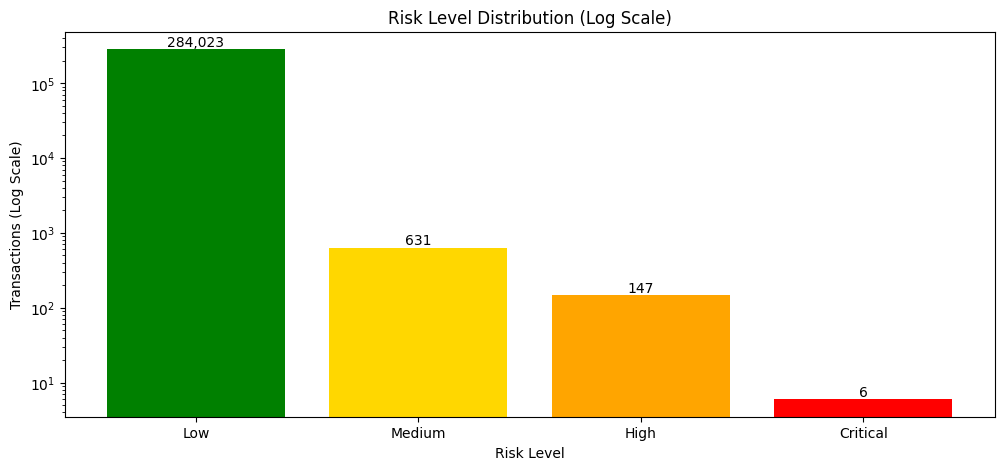

In [ ]:
plt.figure(figsize=(12, 5))

colors = ["green", "gold", "orange", "red"]  # Low  # Medium  # High  # Critical

bars = plt.bar(risk_distribution["RiskLevel"], risk_distribution["count"], color=colors)

plt.yscale("log")

plt.title("Risk Level Distribution (Log Scale)")
plt.xlabel("Risk Level")
plt.ylabel("Transactions (Log Scale)")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:,.0f}",
        ha="center",
        va="bottom",
    )

plt.show()

#### **Executive thinthing**

- A `small percentage of transactions` account for the `highest investigation priority`, allowing `fraud teams` to `focus` resources on the `most suspicious activity` rather than reviewing all transactions.

- `Critical Risk` transactions represent approximately `0.002%` of all transactions (6 out of 284,807).

- `Low Risk` transactions represent approximately `99.72%` of all transactions (284,023 out of 284,807).

-With only `6` Critical Risk transactions, investigators could realistically review every case individually.

- Risk scoring helps banks focus their resources on the most suspicious transactions instead of manually reviewing every transaction, improving efficiency and response times.

- This scoring system relies on simple rules and a limited number of features. It may miss sophisticated fraud patterns, generate false positives, and may not adapt well to changing fraud behavior.

---

## Customer and Population Risk Segmentation

### `Dataset Limitation`

The dataset `does not contain` customer, account, or card `identifiers`.

As a result, `customer-level behavioral analysis` and risk segmentation `cannot be performed`.

To demonstrate segmentation techniques, transactions were grouped into risk categories based on fraud-related characteristics. These segments represent transaction risk rather than customer risk.

**Create Risk Profile Table**

In [ ]:
risk_profile = (
    df.groupby("RiskLevel")
    .agg(
        Transactions=("Class", "count"),
        FraudCount=("Class", "sum"),
        AvgAmount=("Amount", "mean"),
        TotalAmount=("Amount", "sum"),
    )
    .round(2)
)

risk_profile

,Transactions,FraudCount,AvgAmount,TotalAmount
RiskLevel,,,,
Low,284023,0,87.72,24913093.88
Medium,631,339,318.26,200824.19
High,147,147,306.82,45102.07
Critical,6,6,594.98,3569.87


**Fraud Concentration**

In [ ]:
risk_fraud_summary = (
    df.groupby("RiskLevel")["Class"].mean().mul(100).round(2).reset_index()
)

risk_fraud_summary.columns = ["RiskLevel", "Fraud Rate Percent"]

risk_fraud_summary

,RiskLevel,Fraud Rate Percent
0,Low,0.00
1,Medium,53.72
2,High,100.00
3,Critical,100.00


**Visualize Fraud Rate by Risk Level**

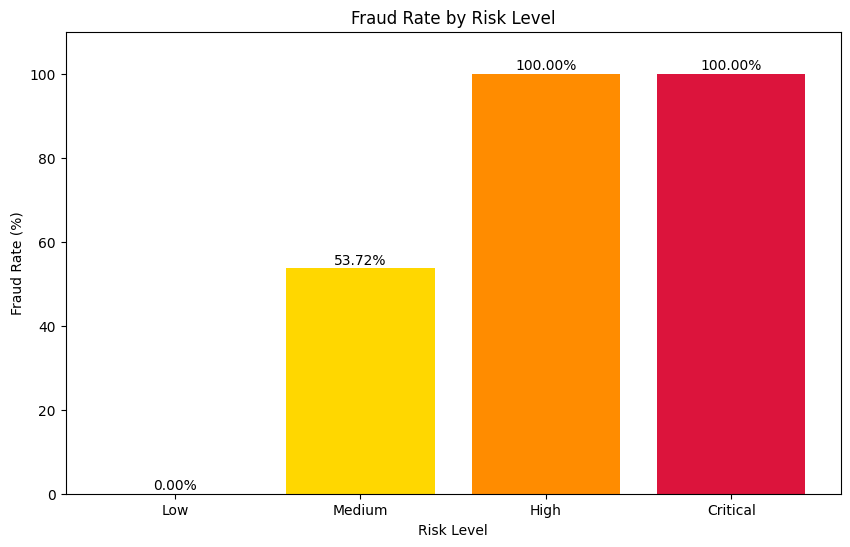

In [55]:
plt.figure(figsize=(10,6))

colors = [
    "#2E8B57",  # Low      -> Green
    "#FFD700",  # Medium   -> Yellow
    "#FF8C00",  # High     -> Orange
    "#DC143C"   # Critical -> Red
]

bars = plt.bar(
    risk_fraud_summary["RiskLevel"],
    risk_fraud_summary["Fraud Rate Percent"],
    color=colors
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 1,
        f"{height:.2f}%",
        ha="center"
    )

plt.title(
    "Fraud Rate by Risk Level"
)

plt.xlabel("Risk Level")

plt.ylabel("Fraud Rate (%)")

plt.ylim(0, 110)

plt.show()

**Exposure by Risk Level**

In [56]:
exposure_summary = (
    df.groupby("RiskLevel")["Amount"]
    .sum()
    .reset_index()
)

exposure_summary

,RiskLevel,Amount
0,Low,24913093.88
1,Medium,200824.19
2,High,45102.07
3,Critical,3569.87


**Executive Risk Matrix**

In [57]:
risk_matrix = pd.DataFrame({
    "Risk Level": [
        "Low",
        "Medium",
        "High",
        "Critical"
    ],

    "Recommended Action": [
        "Automatic Approval",
        "Monitor",
        "Enhanced Monitoring",
        "Immediate Investigation"
    ]
})

risk_matrix

,Risk Level,Recommended Action
0,Low,Automatic Approval
1,Medium,Monitor
2,High,Enhanced Monitoring
3,Critical,Immediate Investigation


- Only a tiny fraction of transactions were classified as `High` or `Critical`, yet these segments captured the majority of fraudulent activity, demonstrating the effectiveness of the risk scoring framework.

- The `Low Risk` segment contains the vast majority of transactions and transaction volume.

- Most fraudulent transactions are concentrated in the `High` and `Critical` risk segments.

- The `Low Risk` segment contains the highest financial exposure, with approximately `24.9M` in transaction value.

- The scoring system effectively concentrates fraud into a small number of higher-risk transactions, reducing the number of records requiring investigation.

- Investigators should prioritize reviews in the following order:
  - `Critical Risk` → Immediate Investigation
  - `High Risk` → Enhanced Monitoring
  - `Medium Risk` → Monitor
  - `Low Risk` → Automatic Approval

---

## Fraud Detection ML

In [58]:
# Create a copy for machine learning.

df_ml = df.copy()

Drop columns that would create leakage

In [60]:
features_to_drop = [
    "Class",
    "RiskScore", #RiskScore was built using fraud information, If we leave it Model sees the answer, That's called Target Leakage.
    "RiskLevel"
]

X = df_ml.drop(
    columns=features_to_drop,
    errors="ignore"
)

y = df_ml["Class"]

**Train/Test Split**

In [61]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

**Verify Class Balance**

In [63]:
y_train.value_counts(normalize=True) * 100

Class
0    99.827075
1     0.172925
Name: proportion, dtype: float64

In [64]:
y_test.value_counts(normalize=True) * 100

Class
0    99.827955
1     0.172045
Name: proportion, dtype: float64

**Train Baseline Model**

In [65]:
from sklearn.ensemble import RandomForestClassifier

In [66]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

**Predictions**

In [68]:
y_pred = rf_model.predict(X_test)
y_pred

array([0, 0, 0, ..., 0, 0, 0], shape=(56962,))

**Evaluation Metrics**

In [69]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

In [70]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

In [71]:
ml_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "Value": [
        accuracy,
        precision,
        recall,
        f1
    ]
})

ml_metrics

,Metric,Value
0,Accuracy,0.999596
1,Precision,0.941176
2,Recall,0.816327
3,F1 Score,0.874317


#### **Classification Report**

In [72]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.94      0.82      0.87        98

    accuracy                           1.00     56962
   macro avg       0.97      0.91      0.94     56962
weighted avg       1.00      1.00      1.00     56962



**Confusion Matrix and Visualization**

In [73]:
from sklearn.metrics import confusion_matrix

In [74]:
cm = confusion_matrix(
    y_test,
    y_pred
)

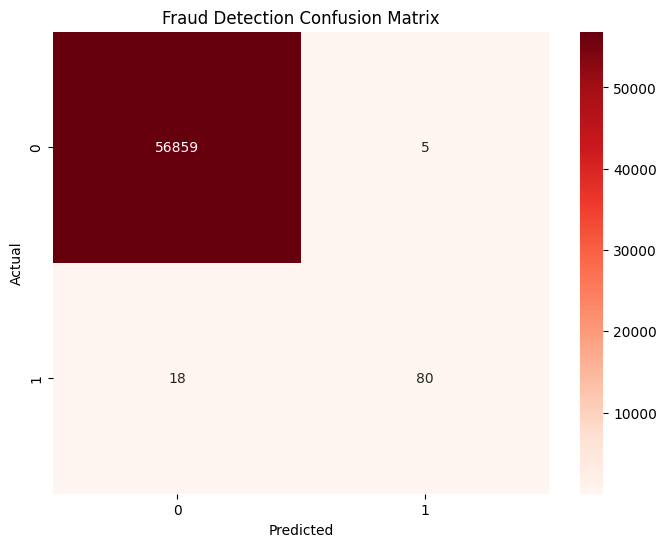

In [75]:
plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Reds"
)

plt.title(
    "Fraud Detection Confusion Matrix"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

**Feature Importance**

In [76]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

In [77]:
feature_importance = (
    feature_importance
    .sort_values(
        by="Importance",
        ascending=False
    )
)

In [78]:
feature_importance.head(15)

,Feature,Importance
12,V12,0.145384
17,V17,0.130247
14,V14,0.124063
10,V10,0.091761
11,V11,0.083478
16,V16,0.047939
9,V9,0.041626
4,V4,0.030502
18,V18,0.027321
7,V7,0.024536


**Visualize Top Features**

In [ ]:
top_features = (
    feature_importance
    .head(15)
)

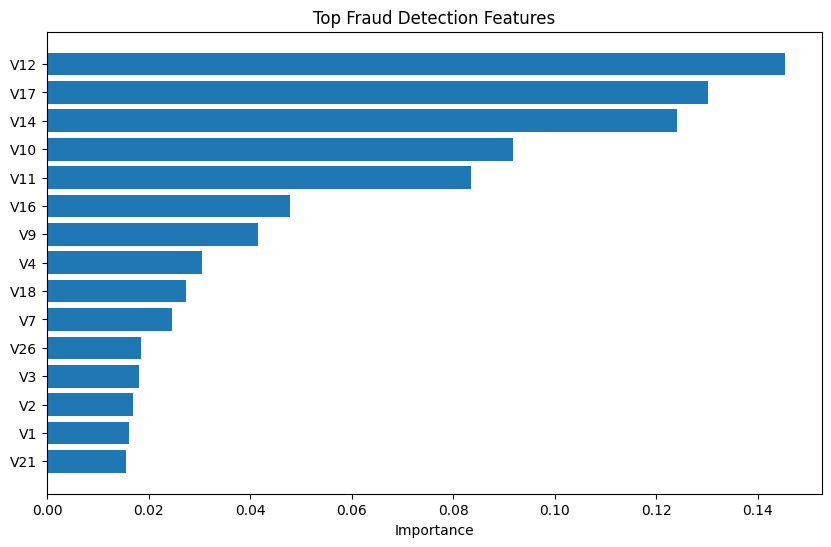

In [80]:
plt.figure(figsize=(10,6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.gca().invert_yaxis()

plt.title(
    "Top Fraud Detection Features"
)

plt.xlabel("Importance")

plt.show()

#### **Analyst Interpretation**

---

## Financial Impact Analysis

---

## Executive Storytelling